In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from diffPLOG2TROE.kinetic_constants import FallOff, Plog
from diffPLOG2TROE.plog_refitter import PlogRefitter

## H+NO

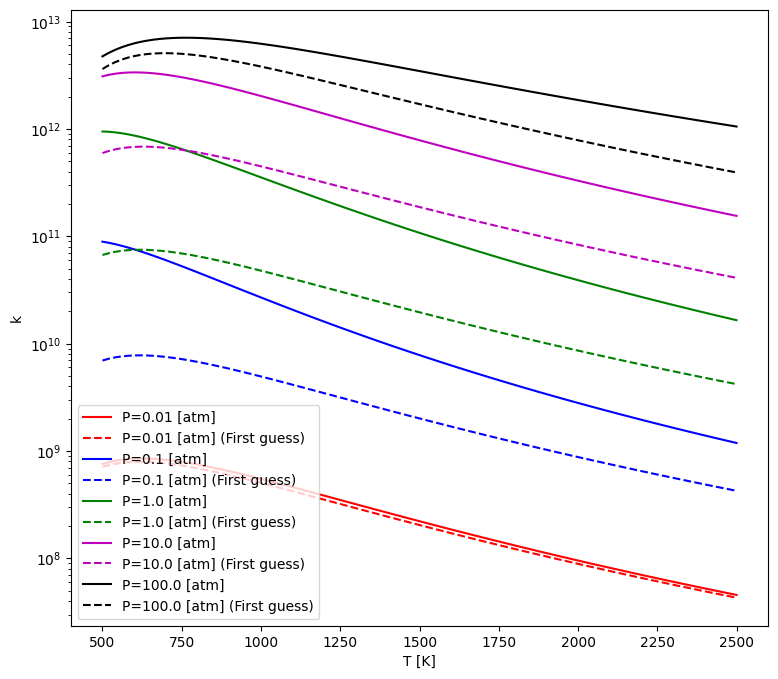

In [2]:
plog = {
    "name": "H+HNO(+M)=H2NO(+M)",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [0.01  ,.5670E+24,  -4.590, 5690.0],
            [0.10  ,.5690E+26,  -4.800, 4233.0],
            [1.00  ,.2680E+28,  -4.940, 4849.0],
            [10.0  ,.2550E+28,  -4.630, 5539.0],
            [100.0 ,.4840E+26,  -3.870, 5867.0],
        ]
    }
}
constant = Plog(plog)

# These values are the one computed directly by the refitter class as its shown in the next cells
troe = FallOff(
    name="H+HNO(+M)=H2NO(+M)",
    hpl_params=jnp.array([8.96943e+18, -1.15415, 5.86665e+03]),
    lpl_params=jnp.array([4.653e+27, -3.590, 5.690e+03]),
    falloff_params=jnp.array([0.100, 1.050e+03, 3.000e+02, 2.250e+03, 0.]),
    falloff_type="troe",
)

T_range = jnp.linspace(500, 2500, 100)
P_range = jnp.logspace(jnp.log10(0.01), jnp.log10(100), 100)
P_levels = jnp.array([0.01, 0.1, 1, 10, 100])

# Let's start by computing the value of the kinetic constant and plotting it
k_plog = constant.kinetic_constant(T_range, P_levels)
k_troe, M = troe.kinetic_constant(T_range, P_levels)

fig, ax = plt.subplots(figsize=(9, 8))

colors = ['r', 'b', 'g', 'm', 'k']

for i, (ki_plog, ki_troe) in enumerate(zip(k_plog, k_troe)):
    ax.plot(T_range, ki_plog, '-', color=colors[i], label=f"P={P_levels[i]} [atm]")
    ax.plot(T_range, ki_troe, '--', color=colors[i], label=f"P={P_levels[i]} [atm] (First guess)")

ax.set_yscale("log")
ax.set_xlabel("T [K]")
ax.set_ylabel("k")
ax.legend()
plt.show()

Known that the high pressure limit for this reaction has been measured when we are going to refit its values into a TROE we are going to fix these values consistently

In [ ]:
troe_param_config = {
    "A": {"optimize": False, "value": 0.5},
    "T3": {"optimize": False, "value": 1.050e+03},
    "T1": {"optimize": False, "value": 300},
    "T2": {"optimize": False, "value": 2250},
}
refitter = PlogRefitter(
    plog_dict=plog,
    T_range=(500, 2500),
    P_range=(0.01, 100),
    fitting_mode="single",
    primary_falloff_type="troe",
    param_config=troe_param_config,
    log_name="OH_NO__OHNO-single.log"
)
results = refitter.optimize(
    max_iterations=50,
    uncertainty_factor=0.5,
    uncertainty_type="symmetric",
    tol=1e-10
)

In [ ]:
params = results["optimized_params"]

troe = FallOff(
    name="OH+NO(+M)=OHNO(+M)",
    lpl_params=jnp.array([jnp.exp(params[0]), params[1], params[2]*1.987]),
    # lpl_params=jnp.array([4.653e+27, -3.590, 5.690e+03]),
    hpl_params=jnp.array([jnp.exp(params[3]), params[4], params[5]*1.987]),
    # hpl_params=jnp.array([jnp.exp(params[0]), params[1], params[2]*1.987]),
    # falloff_params=jnp.array([params[3], params[4], 1e28, 1e28, 0]),
    falloff_params=jnp.array([0.5, 1.050e+03, 300, 2250, 0]),
    falloff_type=1
)

# Let's start by computing the value of the kinetic constant and plotting it
k_plog = constant.kinetic_constant(T_range, P_levels)
k_troe = troe.kinetic_constant(T_range, P_levels)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["r", "b", "g", "m", "c"]

for i, (ki_plog, ki_troe) in enumerate(zip(k_plog, k_troe)):
    ax.plot(T_range, ki_plog, '-', color=colors[i], label=f"P={P_levels[i]} [atm]")
    ax.plot(T_range, ki_troe, '--', color=colors[i], label=f"P={P_levels[i]} [atm] (Final)")
    
ax.set_yscale("log")
ax.set_xlabel("T [K]")
ax.set_ylabel("k")
ax.legend()
plt.show()

print(troe)

In [ ]:
plt.semilogy(results["loss_history"])
plt.xlabel("# Iteration")
plt.ylabel("Loss function")
plt.show()

In [ ]:
T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

k_plog = constant.kinetic_constant(T_range, P_range)
k_troe = troe.kinetic_constant(T_range, P_range)

ratio = k_troe.T / k_plog.T
rel_ratio = jnp.mean(jnp.sqrt((1 - k_troe.T / k_plog.T) ** 2))

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap="Pastel2"
)
    
plt.xscale("log")
plt.xlabel("Pressure [bar]", fontweight="bold")
plt.ylabel("Temperature [K]", fontweight="bold")    
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {rel_ratio}")

plt.tight_layout()
plt.show()